# **Advertising Incrementality Experiment Analysis**

## **Objective**

This notebook estimates the incremental effect of advertising assignment on
website visits and conversions using the Criteo Uplift Prediction Dataset.

The analysis will:

1. Compare treatment and control sample sizes and outcome rates.
2. Estimate absolute and relative lift in visit and conversion rates.
3. Test treatment-control differences using two-proportion z-tests.
4. Calculate 95% confidence intervals for the estimated treatment effects.
5. Translate the statistical results into estimated incremental visits and
   conversions.
6. Evaluate the practical implications and limitations of the experiment.

The primary outcome is **conversion**, while website visit is analyzed as a
secondary funnel outcome.

The main analysis follows an **intention-to-treat approach**, meaning that
observations are analyzed according to their randomized treatment assignment,
regardless of whether they were actually exposed to the advertisement.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## **Data Loading**

Only the experiment assignment, delivery, and outcome variables are loaded
because the overall experiment analysis does not require the anonymized
features `f0` through `f11`.

The analysis uses:

- `treatment`: randomized experiment assignment
- `exposure`: actual advertising exposure
- `visit`: website visit outcome
- `conversion`: final conversion outcome

In [26]:
file_path = "../data/raw/criteo-uplift-v2.1.csv.gz"

experiment_columns = [
    "treatment",
    "exposure",
    "visit",
    "conversion"
]

df = pd.read_csv(
    file_path,
    usecols=experiment_columns
)

print("Experiment data loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())



Experiment data loaded successfully.
Rows: 13,979,592
Columns: 4


,treatment,conversion,visit,exposure
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


### **Experiment Data Consistency Check**

The experiment dataset is checked against the expected structure before
treatment effects are estimated.

In [27]:
experiment_checks = {
    "Total observations": len(df),

    "Missing values": int(
        df.isna().sum().sum()
    ),

    "Invalid treatment values": int(
        (~df["treatment"].isin([0, 1])).sum()
    ),

    "Invalid exposure values": int(
        (~df["exposure"].isin([0, 1])).sum()
    ),

    "Invalid visit values": int(
        (~df["visit"].isin([0, 1])).sum()
    ),

    "Invalid conversion values": int(
        (~df["conversion"].isin([0, 1])).sum()
    ),

    "Control users marked as exposed": int(
        (
            (df["treatment"] == 0)
            & (df["exposure"] == 1)
        ).sum()
    ),

    "Conversions without a visit": int(
        (
            (df["conversion"] == 1)
            & (df["visit"] == 0)
        ).sum()
    )
}

experiment_check_summary = (
    pd.Series(
        experiment_checks,
        name="value"
    )
    .rename_axis("check")
    .reset_index()
)

display(experiment_check_summary)

,check,value
0,Total observations,13979592
1,Missing values,0
2,Invalid treatment values,0
3,Invalid exposure values,0
4,Invalid visit values,0
5,Invalid conversion values,0
6,Control users marked as exposed,0
7,Conversions without a visit,0


In [28]:
quality_check_names = [
    "Missing values",
    "Invalid treatment values",
    "Invalid exposure values",
    "Invalid visit values",
    "Invalid conversion values",
    "Control users marked as exposed",
    "Conversions without a visit"
]

all_quality_checks_passed = (
    experiment_check_summary.loc[
        experiment_check_summary["check"].isin(
            quality_check_names
        ),
        "value"
    ]
    .eq(0)
    .all()
)

print(
    "All experiment quality checks passed:",
    all_quality_checks_passed
)

All experiment quality checks passed: True


The experiment data matches the validated structure from the data-understanding
notebook. No missing values, invalid binary values, control-group exposures,
or conversions without visits were identified.

## **Treatment and Control Summary**

This section compares the size, advertising delivery, and outcome rates of the
control and treatment groups.

Because the treatment and control groups have different sample sizes, visit
and conversion rates are used for comparison instead of raw outcome counts.

In [29]:
experiment_summary = (
    df.groupby("treatment")
    .agg(
        users=("treatment", "size"),
        exposed_users=("exposure", "sum"),
        visitors=("visit", "sum"),
        conversions=("conversion", "sum"),
        exposure_rate=("exposure", "mean"),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean")
    )
    .reset_index()
)

experiment_summary["allocation_rate"] = (
    experiment_summary["users"]
    / experiment_summary["users"].sum()
)

experiment_summary["group"] = (
    experiment_summary["treatment"]
    .map({
        0: "Control",
        1: "Treatment"
    })
)

experiment_summary = experiment_summary[
    [
        "group",
        "users",
        "allocation_rate",
        "exposed_users",
        "exposure_rate",
        "visitors",
        "visit_rate",
        "conversions",
        "conversion_rate"
    ]
]

display(experiment_summary)



,group,users,allocation_rate,exposed_users,exposure_rate,visitors,visit_rate,conversions,conversion_rate
0,Control,2096937,0.150000,0,0.000000,80105,0.038201,4063,0.001938
1,Treatment,11882655,0.850000,428212,0.036037,576824,0.048543,36711,0.003089


In [30]:
experiment_summary_display = (
    experiment_summary.copy()
)

rate_columns = [
    "allocation_rate",
    "exposure_rate",
    "visit_rate",
    "conversion_rate"
]

for column in rate_columns:
    experiment_summary_display[column] = (
        experiment_summary_display[column]
        .map(lambda value: f"{value:.4%}")
    )

count_columns = [
    "users",
    "exposed_users",
    "visitors",
    "conversions"
]

for column in count_columns:
    experiment_summary_display[column] = (
        experiment_summary_display[column]
        .map(lambda value: f"{value:,.0f}")
    )

display(experiment_summary_display)

,group,users,allocation_rate,exposed_users,exposure_rate,visitors,visit_rate,conversions,conversion_rate
0,Control,"2,096,937",15.0000%,0,0.0000%,"80,105",3.8201%,"4,063",0.1938%
1,Treatment,"11,882,655",85.0000%,"428,212",3.6037%,"576,824",4.8543%,"36,711",0.3089%


In [31]:
control = experiment_summary.loc[
    experiment_summary["group"] == "Control"
].iloc[0]

treatment = experiment_summary.loc[
    experiment_summary["group"] == "Treatment"
].iloc[0]

### **Summary Observations**

- The experiment allocated approximately **15%** of observations to the
  control group and **85%** to the treatment group.
- No control observations were marked as exposed.
- Approximately **3.60%** of treatment-assigned observations were actually
  exposed to the advertisement.
- The treatment group had higher observed visit and conversion rates than the
  control group.
- Statistical testing is required before concluding that these observed
  differences are unlikely to be explained by random variation.

## **Conversion Rate Effect**

Conversion is the primary outcome of the experiment.

The analysis evaluates whether assignment to the advertising treatment
increased the probability of conversion.

### Hypotheses

- **Null hypothesis (H₀):** The treatment and control groups have the same
  conversion rate.
- **Alternative hypothesis (H₁):** The treatment and control groups have
  different conversion rates.
- **Significance level:** α = 0.05

A two-sided two-proportion z-test is used to compare the conversion rates.
The treatment effect is reported using absolute lift, relative lift, and a
95% confidence interval.

In [32]:
control_conversion_rate = (
    control["conversion_rate"]
)

treatment_conversion_rate = (
    treatment["conversion_rate"]
)

absolute_conversion_lift = (
    treatment_conversion_rate
    - control_conversion_rate
)

relative_conversion_lift = (
    absolute_conversion_lift
    / control_conversion_rate
)

print(
    "Control conversion rate: "
    f"{control_conversion_rate:.4%}"
)

print(
    "Treatment conversion rate: "
    f"{treatment_conversion_rate:.4%}"
)

print(
    "Absolute conversion lift: "
    f"{absolute_conversion_lift:.4%}"
)

print(
    "Relative conversion lift: "
    f"{relative_conversion_lift:.2%}"
)



Control conversion rate: 0.1938%
Treatment conversion rate: 0.3089%
Absolute conversion lift: 0.1152%
Relative conversion lift: 59.45%


In [33]:
conversion_successes = np.array([
    treatment["conversions"],
    control["conversions"]
])

conversion_observations = np.array([
    treatment["users"],
    control["users"]
])

conversion_z_stat, conversion_p_value = (
    proportions_ztest(
        count=conversion_successes,
        nobs=conversion_observations,
        alternative="two-sided"
    )
)

print(
    "Conversion z-statistic: "
    f"{conversion_z_stat:.4f}"
)

print(
    "Conversion p-value: "
    f"{conversion_p_value:.2e}"
)

Conversion z-statistic: 28.5165
Conversion p-value: 7.31e-179


A two-proportion z-test found a statistically significant difference in conversion rates between the treatment and control groups (z = 28.52, p < 0.001). Since the z-statistic is positive and the treatment group was entered first, the treatment group had a significantly higher conversion rate than the control group.

In [34]:
conversion_ci_low, conversion_ci_high = (
    confint_proportions_2indep(
        count1=int(
            treatment["conversions"]
        ),
        nobs1=int(
            treatment["users"]
        ),
        count2=int(
            control["conversions"]
        ),
        nobs2=int(
            control["users"]
        ),
        method="wald",
        compare="diff",
        alpha=0.05
    )
)

print(
    "95% CI for absolute conversion lift: "
    f"[{conversion_ci_low:.4%}, "
    f"{conversion_ci_high:.4%}]"
)

95% CI for absolute conversion lift: [0.1085%, 0.1219%]


The treatment increased the conversion rate by approximately 0.115 percentage points, with a 95% confidence interval of 0.109 to 0.122 percentage points. Since the interval does not include zero, the treatment effect is statistically significant.

In [35]:
conversion_result = pd.DataFrame({
    "metric": ["Conversion Rate"],
    "control_rate": [
        control_conversion_rate
    ],
    "treatment_rate": [
        treatment_conversion_rate
    ],
    "absolute_lift": [
        absolute_conversion_lift
    ],
    "relative_lift": [
        relative_conversion_lift
    ],
    "ci_lower": [
        conversion_ci_low
    ],
    "ci_upper": [
        conversion_ci_high
    ],
    "z_statistic": [
        conversion_z_stat
    ],
    "p_value": [
        conversion_p_value
    ]
})

conversion_result["statistically_significant"] = (
    conversion_result["p_value"] < 0.05
)

display(conversion_result)

,metric,control_rate,treatment_rate,absolute_lift,relative_lift,ci_lower,ci_upper,z_statistic,p_value,statistically_significant
0,Conversion Rate,0.001938,0.003089,0.001152,0.594488,0.001085,0.001219,28.516529,0.000000,True


### **Conversion Result Interpretation**

The treatment group achieved a conversion rate of approximately **0.309%**,
compared with **0.194%** in the control group.

This represents:

- An absolute increase of approximately **0.115 percentage points**
- A relative increase of approximately **59.45%**

The two-proportion z-test rejected the null hypothesis (`p < 0.001`).
The 95% confidence interval for the absolute lift ranged from approximately
**0.109 to 0.122 percentage points** and did not include zero.

Therefore, assignment to the advertising treatment produced a statistically
significant positive effect on conversion rate.

## **Visit Rate Effect**

Website visit is analyzed as a secondary funnel outcome.

The analysis evaluates whether assignment to the advertising treatment
increased the probability of visiting the advertiser's website.

### Hypotheses

- **Null hypothesis (H₀):** The treatment and control groups have the same
  visit rate.
- **Alternative hypothesis (H₁):** The treatment and control groups have
  different visit rates.
- **Significance level:** α = 0.05

A two-sided two-proportion z-test is used to compare treatment and control
visit rates.

In [36]:
control_visit_rate = (
    control["visit_rate"]
)

treatment_visit_rate = (
    treatment["visit_rate"]
)

absolute_visit_lift = (
    treatment_visit_rate
    - control_visit_rate
)

relative_visit_lift = (
    absolute_visit_lift
    / control_visit_rate
)

print(
    "Control visit rate: "
    f"{control_visit_rate:.4%}"
)

print(
    "Treatment visit rate: "
    f"{treatment_visit_rate:.4%}"
)

print(
    "Absolute visit lift: "
    f"{absolute_visit_lift:.4%}"
)

print(
    "Relative visit lift: "
    f"{relative_visit_lift:.2%}"
)

Control visit rate: 3.8201%
Treatment visit rate: 4.8543%
Absolute visit lift: 1.0342%
Relative visit lift: 27.07%


In [37]:
visit_successes = np.array([
    treatment["visitors"],
    control["visitors"]
])

visit_observations = np.array([
    treatment["users"],
    control["users"]
])

visit_z_stat, visit_p_value = (
    proportions_ztest(
        count=visit_successes,
        nobs=visit_observations,
        alternative="two-sided"
    )
)

print(
    "Visit z-statistic: "
    f"{visit_z_stat:.4f}"
)

print(
    "Visit p-value: "
    f"{visit_p_value:.2e}"
)



Visit z-statistic: 65.2474
Visit p-value: 0.00e+00


In [38]:
visit_ci_low, visit_ci_high = (
    confint_proportions_2indep(
        count1=int(
            treatment["visitors"]
        ),
        nobs1=int(
            treatment["users"]
        ),
        count2=int(
            control["visitors"]
        ),
        nobs2=int(
            control["users"]
        ),
        method="wald",
        compare="diff",
        alpha=0.05
    )
)

print(
    "95% CI for absolute visit lift: "
    f"[{visit_ci_low:.4%}, "
    f"{visit_ci_high:.4%}]"
)

95% CI for absolute visit lift: [1.0056%, 1.0629%]


In [39]:
visit_result = pd.DataFrame({
    "metric": ["Visit Rate"],
    "control_rate": [
        control_visit_rate
    ],
    "treatment_rate": [
        treatment_visit_rate
    ],
    "absolute_lift": [
        absolute_visit_lift
    ],
    "relative_lift": [
        relative_visit_lift
    ],
    "ci_lower": [
        visit_ci_low
    ],
    "ci_upper": [
        visit_ci_high
    ],
    "z_statistic": [
        visit_z_stat
    ],
    "p_value": [
        visit_p_value
    ]
})

visit_result["statistically_significant"] = (
    visit_result["p_value"] < 0.05
)

display(visit_result)

,metric,control_rate,treatment_rate,absolute_lift,relative_lift,ci_lower,ci_upper,z_statistic,p_value,statistically_significant
0,Visit Rate,0.038201,0.048543,0.010342,0.270737,0.010056,0.010629,65.247430,0.000000,True


### **Visit Result Interpretation**

The treatment group achieved a website visit rate of approximately **4.85%**,
compared with **3.82%** in the control group.

This represents:

- An absolute increase of approximately **1.03 percentage points**
- A relative increase of approximately **27.07%**

The two-proportion z-test rejected the null hypothesis (`p < 0.001`).
The 95% confidence interval for the absolute lift ranged from approximately
**1.01 to 1.06 percentage points** and did not include zero.

Therefore, assignment to the advertising treatment produced a statistically
significant positive effect on website visit rate.

## **Experiment Results Summary**

The visit-rate and conversion-rate results are combined into a single summary
table for comparison and export.

The table reports:

- Control and treatment rates
- Absolute and relative lift
- 95% confidence intervals
- Z-statistics and p-values
- Statistical significance

In [40]:
results_summary = pd.concat(
    [
        visit_result,
        conversion_result
    ],
    ignore_index=True
)

results_summary["effect_direction"] = np.where(
    results_summary["absolute_lift"] > 0,
    "Positive",
    np.where(
        results_summary["absolute_lift"] < 0,
        "Negative",
        "No Difference"
    )
)

results_summary_display = (
    results_summary.copy()
)

In [41]:
results_summary_display = (
    results_summary.copy()
)

rate_columns = [
    "control_rate",
    "treatment_rate",
    "absolute_lift",
    "ci_lower",
    "ci_upper"
]

for column in rate_columns:
    results_summary_display[column] = (
        results_summary_display[column]
        .map(lambda value: f"{value:.4%}")
    )

results_summary_display["relative_lift"] = (
    results_summary_display["relative_lift"]
    .map(lambda value: f"{value:.2%}")
)

results_summary_display["z_statistic"] = (
    results_summary_display["z_statistic"]
    .map(lambda value: f"{value:.4f}")
)

results_summary_display["p_value"] = (
    results_summary_display["p_value"]
    .map(lambda value: f"{value:.2e}")
)

display(results_summary_display)

,metric,control_rate,treatment_rate,absolute_lift,relative_lift,ci_lower,ci_upper,z_statistic,p_value,statistically_significant,effect_direction
0,Visit Rate,3.8201%,4.8543%,1.0342%,27.07%,1.0056%,1.0629%,65.2474,0.00e+00,True,Positive
1,Conversion Rate,0.1938%,0.3089%,0.1152%,59.45%,0.1085%,0.1219%,28.5165,7.31e-179,True,Positive


In [42]:
experiment_summary.to_csv(
    "../data/processed/experiment_group_summary.csv",
    index=False
)

results_summary.to_csv(
    "../data/processed/experiment_test_results.csv",
    index=False
)

print(
    "Exported:"
    "\n- experiment_group_summary.csv"
    "\n- experiment_test_results.csv"
)

Exported:
- experiment_group_summary.csv
- experiment_test_results.csv


### **Summary Interpretation**

Advertising treatment assignment produced statistically significant increases
in both website visits and conversions.

- Visit rate increased by approximately **1.03 percentage points**, equivalent
  to a **27.07% relative lift**.
- Conversion rate increased by approximately **0.115 percentage points**,
  equivalent to a **59.45% relative lift**.
- Both 95% confidence intervals excluded zero.
- Both hypothesis tests rejected the null hypothesis at the 5% significance
  level.

Although the absolute conversion-rate increase appears small, conversion is a
rare outcome and the relative improvement is substantial. Practical impact is
evaluated in the following section using estimated incremental visits and
conversions.

## **Treatment vs Control Visualization**

The following charts compare treatment and control outcome rates.

- Gray represents the control group.
- Orange represents the treatment group.
- Labels above the bars show the observed outcome rates.

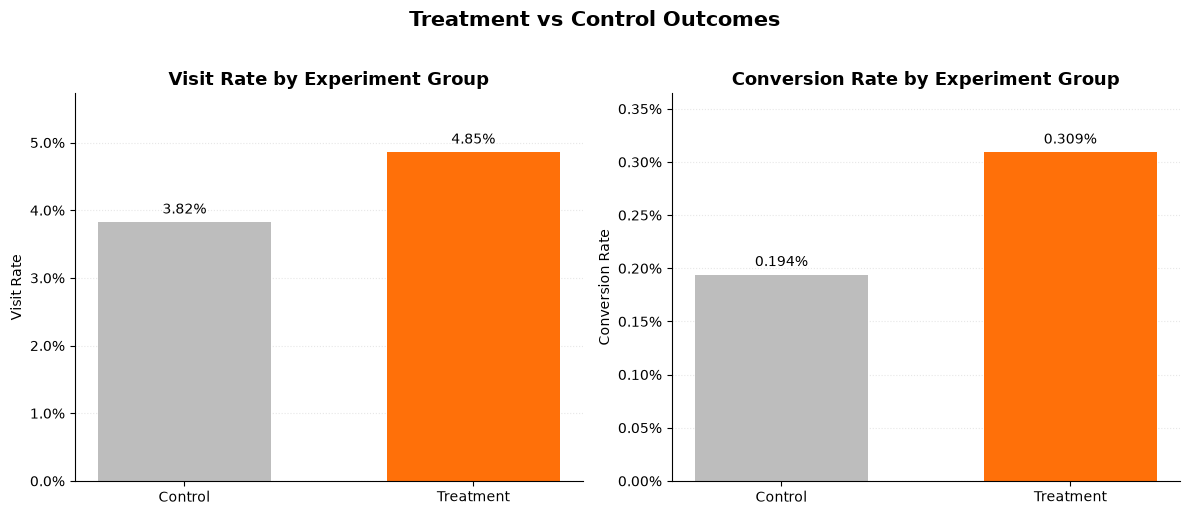

In [43]:
colors = [
    "#BDBDBD",
    "#FF7009"
]

groups = experiment_summary["group"]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)



visit_bars = axes[0].bar(
    groups,
    experiment_summary["visit_rate"],
    color=colors,
    width=0.6
)

axes[0].set_title(
    "Visit Rate by Experiment Group",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Visit Rate"
)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.1%}"
    )
)

axes[0].bar_label(
    visit_bars,
    labels=[
        f"{value:.2%}"
        for value in experiment_summary["visit_rate"]
    ],
    padding=4,
    fontsize=10
)

axes[0].set_ylim(
    0,
    experiment_summary["visit_rate"].max() * 1.18
)

axes[0].grid(
    axis="y",
    linestyle=":",
    alpha=0.3
)

axes[0].set_axisbelow(True)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)




conversion_bars = axes[1].bar(
    groups,
    experiment_summary["conversion_rate"],
    color=colors,
    width=0.6
)

axes[1].set_title(
    "Conversion Rate by Experiment Group",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Conversion Rate"
)

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.2%}"
    )
)

axes[1].bar_label(
    conversion_bars,
    labels=[
        f"{value:.3%}"
        for value in experiment_summary["conversion_rate"]
    ],
    padding=4,
    fontsize=10
)

axes[1].set_ylim(
    0,
    experiment_summary["conversion_rate"].max() * 1.18
)

axes[1].grid(
    axis="y",
    linestyle=":",
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)




fig.suptitle(
    "Treatment vs Control Outcomes",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()


plt.savefig(
    "../outputs/figures/treatment_control_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Visualization Interpretation**

The treatment group achieved higher observed rates for both funnel outcomes:

- Visit rate increased from approximately **3.82% to 4.85%**.
- Conversion rate increased from approximately **0.194% to 0.309%**.

The conversion-rate difference is visually smaller because conversion is a
rare outcome. However, the relative conversion lift of approximately **59.45%**
is larger than the relative visit lift of approximately **27.07%**.

The statistical tests and confidence intervals confirm that both differences
are statistically significant.

## **Practical Business Impact**

Statistical significance does not automatically indicate business value.

This section translates the estimated treatment effects into practical impact
metrics for the treatment-assigned population.

The calculations use the intention-to-treat effects and therefore represent
the estimated impact of assignment to the advertising strategy rather than
the effect of guaranteed advertisement exposure.

In [44]:
treatment_users = int(
    treatment["users"]
)

incremental_visits = (
    absolute_visit_lift
    * treatment_users
)

incremental_conversions = (
    absolute_conversion_lift
    * treatment_users
)

incremental_visits_per_100k = (
    absolute_visit_lift
    * 100_000
)

incremental_conversions_per_100k = (
    absolute_conversion_lift
    * 100_000
)

users_per_incremental_conversion = (
    1 / absolute_conversion_lift
    if absolute_conversion_lift > 0
    else np.nan
)

In [45]:
print(
    "Treatment-assigned observations: "
    f"{treatment_users:,}"
)

print(
    "Estimated incremental visits: "
    f"{incremental_visits:,.0f}"
)

print(
    "Estimated incremental conversions: "
    f"{incremental_conversions:,.0f}"
)

print(
    "Incremental visits per 100,000 treatment assignments: "
    f"{incremental_visits_per_100k:,.0f}"
)

print(
    "Incremental conversions per 100,000 treatment assignments: "
    f"{incremental_conversions_per_100k:,.0f}"
)

print(
    "Users needed for one incremental conversion: "
    f"{users_per_incremental_conversion:,.0f}"
)

Treatment-assigned observations: 11,882,655
Estimated incremental visits: 122,895
Estimated incremental conversions: 13,687
Incremental visits per 100,000 treatment assignments: 1,034
Incremental conversions per 100,000 treatment assignments: 115
Users needed for one incremental conversion: 868


In [46]:
business_impact = pd.DataFrame({
    "metric": [
        "Incremental Visits",
        "Incremental Conversions",
        "Incremental Visits per 100K Assignments",
        "Incremental Conversions per 100K Assignments",
        "Users per Incremental Conversion"
    ],
    "value": [
        incremental_visits,
        incremental_conversions,
        incremental_visits_per_100k,
        incremental_conversions_per_100k,
        users_per_incremental_conversion
    ]
})

display(business_impact)

,metric,value
0,Incremental Visits,"122,895.208255"
1,Incremental Conversions,"13,687.310082"
2,Incremental Visits per 100K Assignments,"1,034.240313"
3,Incremental Conversions per 100K Assignments,115.187305
4,Users per Incremental Conversion,868.151224


In [47]:
expected_treatment_conversions_at_control_rate = (
    control_conversion_rate
    * treatment_users
)

observed_treatment_conversions = (
    treatment["conversions"]
)

incremental_conversions_check = (
    observed_treatment_conversions
    - expected_treatment_conversions_at_control_rate
)

print(
    "Expected treatment conversions at control rate: "
    f"{expected_treatment_conversions_at_control_rate:,.0f}"
)

print(
    "Observed treatment conversions: "
    f"{observed_treatment_conversions:,.0f}"
)

print(
    "Estimated incremental conversions: "
    f"{incremental_conversions_check:,.0f}"
)

Expected treatment conversions at control rate: 23,024
Observed treatment conversions: 36,711
Estimated incremental conversions: 13,687


In [48]:
business_impact.to_csv(
    "../data/processed/experiment_business_impact.csv",
    index=False
)

print(
    "Exported: "
    "experiment_business_impact.csv"
)

Exported: experiment_business_impact.csv


### **Business Impact Interpretation**

Applied to the **11.88 million treatment-assigned observations**, the estimated
treatment effects correspond to approximately:

- **122,895 incremental website visits**
- **13,687 incremental conversions**
- **1,034 incremental visits per 100,000 treatment assignments**
- **115 incremental conversions per 100,000 treatment assignments**

Approximately **868 treatment assignments** were required to generate one
additional conversion.

These results indicate that the treatment produced meaningful incremental
volume at scale. However, the dataset does not include advertising cost,
conversion value, customer lifetime value, or profit margin.

Therefore, the analysis cannot determine whether the campaign was financially
profitable. A full rollout decision should compare the value of an incremental
conversion with the cost of reaching approximately 868 treatment-assigned
users.

### **Break-Even Decision Rule**

If the average value of one incremental conversion is known, the maximum
break-even advertising cost per treatment assignment can be calculated as:

$$
\text{Maximum total advertising cost}
= \text{Incremental conversions}
\times \text{Value per conversion}
$$


Because conversion value and advertising cost are not included in the dataset,
this project reports the decision framework but does not calculate ROI.

## **Key Findings**

- The treatment group achieved a website visit rate of approximately **4.85%**,
  compared with **3.82%** in the control group.

- This represents an absolute visit-rate lift of approximately
  **1.03 percentage points** and a relative lift of **27.07%**.

- The treatment group achieved a conversion rate of approximately **0.309%**,
  compared with **0.194%** in the control group.

- This represents an absolute conversion-rate lift of approximately
  **0.115 percentage points** and a relative lift of **59.45%**.

- The treatment effects on both visit and conversion rates were statistically
  significant (`p < 0.001`).

- The 95% confidence intervals for both treatment effects excluded zero,
  supporting positive incremental effects:

  - Visit-rate lift: approximately **1.006 to 1.063 percentage points**
  - Conversion-rate lift: approximately **0.109 to 0.122 percentage points**

- Applied to the 11.88 million treatment-assigned observations, the estimated
  effects correspond to approximately:

  - **122,895 incremental website visits**
  - **13,687 incremental conversions**

- For every 100,000 treatment assignments, the advertising strategy generated
  an estimated:

  - **1,034 incremental visits**
  - **115 incremental conversions**

- Approximately **868 treatment assignments** were required to generate one
  additional conversion.

## **Business Recommendations**

1. **Continue validating the advertising strategy at scale.**  
   The experiment produced statistically significant and practically
   meaningful increases in both website visits and conversions.

2. **Use conversion as the primary campaign decision metric.**  
   Visit rate provides useful upper-funnel information, but incremental
   conversion is more closely connected to business value.

3. **Evaluate campaign economics before full rollout.**  
   Approximately 868 treatment assignments were required to generate one
   incremental conversion. This result should be combined with advertising
   cost, conversion value, profit margin, and customer lifetime value to
   determine whether the campaign is financially profitable.

4. **Preserve a randomized control group.**  
   Future campaign deployments should maintain a persistent holdout group so
   that incremental performance can continue to be measured instead of relying
   only on attributed conversions.

5. **Investigate treatment-effect heterogeneity.**  
   The average treatment effect may conceal meaningful differences across user
   groups. Segment-level analysis and uplift modeling should be used to identify
   users with the greatest incremental response.

6. **Investigate treatment delivery.**  
   Only approximately 3.60% of treatment-assigned observations were marked as
   actually exposed. Future analysis should evaluate whether delivery coverage
   can be improved without sacrificing targeting quality or campaign
   efficiency.

7. **Run a follow-up randomized experiment after targeting changes.**  
   Any targeting strategy derived from segment or uplift analysis should be
   validated in a new experiment before production deployment.

## **Limitations**

- **Intention-to-treat estimation:**  
  The analysis estimates the effect of assignment to the advertising strategy,
  not the effect of guaranteed advertisement exposure.

- **Incomplete treatment delivery:**  
  Only a small proportion of treatment-assigned observations were marked as
  exposed. As a result, the intention-to-treat estimate may be diluted relative
  to the effect among users who actually received the advertisement.

- **Exposure is not independently randomized:**  
  Exposed treatment users should not be compared directly with control users
  without additional causal methods because actual exposure may be associated
  with post-assignment behavior or delivery conditions.

- **Unequal experiment allocation:**  
  Approximately 85% of observations were assigned to treatment and 15% to
  control. Rate-based estimation remains valid, but raw outcome counts should
  not be compared directly.

- **Rare conversion outcome:**  
  Conversion occurs for less than 1% of observations. The large sample enables
  precise estimation, but smaller segment-level samples may have greater
  uncertainty.

- **No campaign-cost information:**  
  Advertising spend, cost per impression, cost per exposed user, and cost per
  treatment assignment are unavailable.

- **No conversion-value information:**  
  Revenue, profit margin, customer lifetime value, and the financial value of
  an incremental conversion are unavailable. Therefore, ROI and profitability
  cannot be calculated.

- **No time dimension:**  
  The dataset does not include dates or timestamps. Experiment duration,
  seasonality, time trends, and long-term treatment effects cannot be assessed.

- **Anonymized user features:**  
  The available feature variables cannot be translated directly into
  interpretable demographic or behavioral targeting rules.

- **External validity:**  
  The results describe this experiment population and campaign setting.
  Performance may differ in other markets, time periods, or advertising
  environments.

## **Conclusion**

The randomized experiment provides strong evidence that assignment to the
advertising treatment increased both website visits and conversions.

Treatment increased visit rate from approximately **3.82% to 4.85%** and
conversion rate from approximately **0.194% to 0.309%**. Both effects were
statistically significant, and their 95% confidence intervals excluded zero.

At the observed experiment scale, the treatment generated an estimated
**122,895 incremental visits** and **13,687 incremental conversions**.
Approximately **868 treatment assignments** were required to produce one
additional conversion.

These results demonstrate that the advertising strategy generated positive
incremental customer response. However, statistical and operational
effectiveness does not automatically imply financial profitability. Campaign
cost and conversion value are required to determine whether the incremental
conversions justify the advertising investment.

The recommended next step is to investigate treatment-effect heterogeneity
across user segments, identify groups with the strongest incremental response,
and validate any proposed targeting strategy in a new randomized experiment.